In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

from sklearn.metrics import class_likelihood_ratios, recall_score, precision_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)

from likelihood_ratios import calc_likelihood_ratios

In [2]:
bootstrap_columns = [f"target_bootstrap_{n}" for n in range(1000)]

In [3]:
from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler((0, 1))

# Gram Positive

In [4]:
gp_results = pd.read_csv(
    "gp_bootstrap_results_df.csv",
    #sep="\t",
)

#gp_results[bootstrap_columns] = scaler.fit_transform(gp_results[bootstrap_columns])


In [5]:
#gp_results = gp_results[gp_results['Bacteremia Rate'] > 0.5]

In [6]:

gp_bs_df, gp_lr_df = calc_likelihood_ratios(
    gp_results,
    "gram_positive",
    "Gram Positive",
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    bootstrap_columns,
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)


In [12]:
recall_score(
    gp_results["gram_positive"], np.where(gp_results["Gram Pos Rate"] > 0.0, 1, 0)
)

0.8333333333333334

In [13]:
from imblearn.metrics import sensitivity_score, specificity_score

combined_results = gp_results.copy()
label_col = "gram_positive"
outcome_col = "Gram Pos Rate"

sensitivities = []
specificities = []
cutoffs = []

for i in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:

    specificities.append(specificity_score(
        combined_results[label_col], np.where(combined_results[outcome_col] > i, 1, 0)
    ))

    sensitivities.append(sensitivity_score(
        combined_results[label_col], np.where(combined_results[outcome_col] > i, 1, 0)
    ))

    cutoffs.append(i)

metrics_df = pd.DataFrame(
    {
        "cutoff": cutoffs,
        "Sensitivity": sensitivities,
        "Specificity": specificities,
    }
)

In [14]:
metrics_df = metrics_df.melt(
    id_vars=["cutoff"],
    value_vars=["Sensitivity", "Specificity"],
    var_name="metric",
    value_name="value",
)

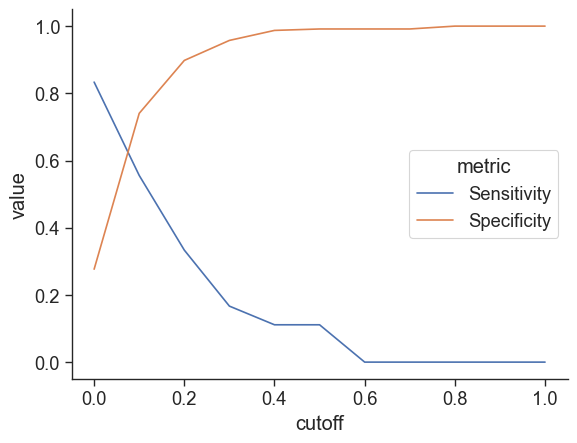

In [15]:
g = sns.lineplot(
    data=metrics_df,
    x="cutoff",
    y="value",
    hue="metric",
)

#g.get_figure().savefig("30_day_mortality_sensitivity_specificity.png")

In [16]:
from sklearn.metrics import roc_auc_score

roc_auc_score(combined_results[label_col], combined_results[outcome_col])

0.6529550827423168

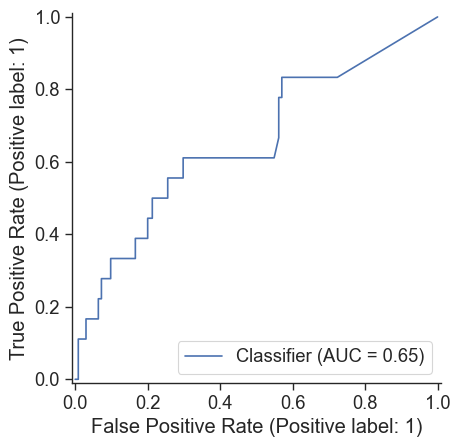

In [17]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    combined_results[label_col],
    combined_results[outcome_col],
)

In [11]:
from sklearn.metrics import roc_auc_score

roc_auc_score(gp_results["gram_positive"], gp_results["Gram Pos Rate"])

0.6529550827423168

In [28]:
gn_results = pd.read_csv(
    "gn_bootstrap_results_df.csv",
    #sep="\t",
)

#gn_results[bootstrap_columns] = scaler.fit_transform(gn_results[bootstrap_columns])

#gn_results = gn_results[gn_results['Bacteremia Rate'] > 0.0]

gn_bs_df, gn_lr_df = calc_likelihood_ratios(
    gn_results,
    "gram_negative",
    "Gram Negative",
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
    bootstrap_columns,
)

In [29]:
recall_score(
    gn_results["gram_negative"], np.where(gn_results["Gram Neg Rate"] > 0.0, 1, 0)
)

0.9523809523809523

In [31]:
lr_combined = pd.concat(
    [gp_lr_df, gn_lr_df],
    ignore_index=True,
)

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_39151/1119246816.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_39151/1119246816.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(


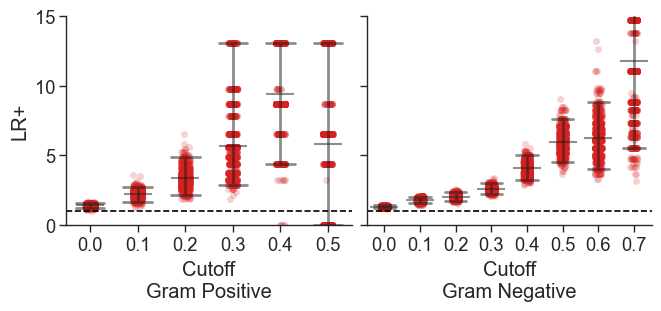

In [32]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    constrained_layout=True,
    sharey="row",
)

axs = axs.ravel()


sns.pointplot(
    data=gp_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[0],
    alpha=0.5,
)

sns.stripplot(
    data=gp_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[0],
    color="#D52221",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)

axs[0].set_xlabel("Cutoff\nGram Positive")

axs[0].axhline(y=1, linestyle='--', color='black')
axs[0].set_xticklabels(
    [f"{val:.1f}" for val in gp_lr_df['Cutoff']],
)

sns.pointplot(
    data=gn_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[1],
    alpha=0.5,
)

sns.stripplot(
    data=gn_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[1],
    color="#D52221",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1
)

axs[1].set_xlabel("Cutoff\nGram Negative")

# axs[3].sharey(axs[2])
# axs[3].set_ylabel("")
# #axs[3].set_yticklabels([])
axs[1].set_ylim(0,15)

axs[1].axhline(y=1, linestyle='--', color='black')
axs[1].set_xticklabels(
    [f"{val:.1f}" for val in gn_lr_df['Cutoff']],
)

fig.set_size_inches(
    (6.5, 3)
)

fig.savefig(
    "infection_metrics.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)


In [33]:
lr_results = pd.read_csv(
    "lower_resp_bootstrap_results_df.csv",
    #sep="\t",
)

lr_bs_df, lr_lr_df = calc_likelihood_ratios(
    lr_results,
    "lower_resp",
    "Lower Respiratory",
    [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    bootstrap_columns,
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Doc

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_39151/1863314829.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


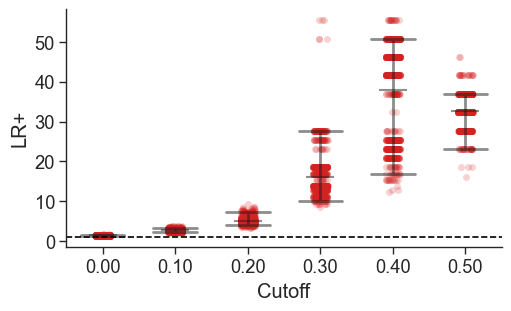

In [39]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    #width_ratios=[0.15, 0.15, 1],
    constrained_layout=True,
    #sharey="row",
)

#axs = axs.ravel()

sns.pointplot(
    data=lr_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs,
    alpha=0.5,
)

sns.stripplot(
    data=lr_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#D52221",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1

)

axs.set_xlabel("Cutoff")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.2f}" for val in gp_lr_df['Cutoff']],
)


#axs[3].set_xlabel("Cutoff\nGram Negative")

# axs[3].sharey(axs[2])
# axs[3].set_ylabel("")
# #axs[3].set_yticklabels([])
# axs[2].set_ylim(0, 25)

# axs[3].axhline(y=1, linestyle='--', color='black')
# axs[3].set_xticklabels(
#     [f"{val:.2f}" for val in gn_lr_df['Cutoff']],
# )

fig.set_size_inches(
    (5, 3)
)

fig.savefig(
    "lower_resp_lrs.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

In [35]:
recall_score(
    lr_results["lower_resp"], np.where(lr_results["Lower Resp Rate"] > 0.0, 1, 0)
)

0.7777777777777778